# Análisis de Componentes Principales Para Clusteres 

In [ ]:
!pip install pyreadstat

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pyreadstat
from IPython.core.display import display, HTML
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json
import os
import requests
import plotly.io as pio
pio.renderers.default = "notebook"  # Para Jupyter Notebook
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
# Set the renderer explicitly
pio.renderers.default = 'notebook'
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import geopandas as gpd
import unicodedata
from sklearn.decomposition import PCA


C:\Users\henry\AppData\Local\Temp\ipykernel_13888\1063230837.py:11: DeprecationWarning:

Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display



In [38]:
data_path = 'C:/Users/henry/Documents/jbook/Cacervix/datos/'
data = pd.read_excel(data_path + 'data_final.xlsx')
rural_data = pd.read_excel(data_path + "rural_data_cluster_general_k3.xlsx")
urbana_data = pd.read_excel(data_path + "urban_data_cluster_general_k2.xlsx")

In [20]:
urbana_data

,DEPARTAMENTO,DEPARTAMENTO DE RESIDENCIA,MUNICIPIO,MUNICIPIO DE RESIDENCIA,AÑO,MES,SEX,ESTADO_CIVIL,NIVEL_EDUCACION,GRUPO_ETARIO,...,C_PAT1_DESCRIPCION,C_ANT3_DESCRIPCION,C_ANT2_DESCRIPCION,C_ANT1_DESCRIPCION,C_DIR1_DESCRIPCION,Total Mujeres,PIB,TIENE_COMORBILIDAD,NUM_COMORBILIDADES,CLUSTER
0,META,META,GRANADA,GRANADA,1985,1,Femenino,Soltero,Primaria,70-74,...,No patología,No patología,No patología,No patología,No patología,192905,74.126,False,0,1
1,BOYACÁ,BOYACÁ,TUNJA,TUNJA,1985,1,Femenino,Soltero,Primaria,60-64,...,No patología,No patología,No patología,No patología,No patología,546762,149.629,False,0,1
2,HUILA,HUILA,NEIVA,NEIVA,1985,1,Femenino,Casado,Primaria,70-74,...,No patología,No patología,No patología,No patología,No patología,345484,120.326,False,0,1
3,HUILA,HUILA,NEIVA,NEIVA,1985,1,Femenino,Casado,Secundaria,45-49,...,No patología,No patología,No patología,No patología,No patología,345484,120.326,False,0,1
4,HUILA,HUILA,AGRADO,AGRADO,1985,1,Femenino,Casado,Primaria,55-59,...,No patología,No patología,No patología,No patología,No patología,345484,120.326,False,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49406,RISARALDA,RISARALDA,PEREIRA,PEREIRA,2023,12,Femenino,Soltero,Primaria,35-39,...,No patología,No patología,No patología,No patología,No patología,191824,26404.000,False,0,1
49407,AMAZONAS,AMAZONAS,LETICIA,LETICIA,2023,4,Femenino,Soltero,Superior,50-54,...,No patología,No patología,No patología,No patología,No patología,3543877,1213.000,False,0,1
49408,META,META,VILLAVICENCIO,VILLAVICENCIO,2023,11,Femenino,Viudo,Secundaria,45-49,...,No patología,No patología,No patología,No patología,No patología,495605,53797.000,False,0,1
49409,VALLE DEL CAUCA,VALLE DEL CAUCA,CALI,CALI,2023,1,Femenino,"Unión Libre, divorciado, otro",Primaria,75-79,...,No patología,No patología,No patología,No patología,No patología,46584,153564.000,False,0,1


In [21]:
rural_data

,DEPARTAMENTO,DEPARTAMENTO DE RESIDENCIA,MUNICIPIO,MUNICIPIO DE RESIDENCIA,AÑO,MES,SEX,ESTADO_CIVIL,NIVEL_EDUCACION,GRUPO_ETARIO,...,C_PAT1_DESCRIPCION,C_ANT3_DESCRIPCION,C_ANT2_DESCRIPCION,C_ANT1_DESCRIPCION,C_DIR1_DESCRIPCION,Total Mujeres,PIB,TIENE_COMORBILIDAD,NUM_COMORBILIDADES,CLUSTER
0,META,META,RESTREPO,RESTREPO,1985,1,Femenino,Casado,Primaria,55-59,...,No patología,No patología,No patología,No patología,No patología,192905,74.126,False,0,2
1,CUNDINAMARCA,CUNDINAMARCA,TOCAIMA,TOCAIMA,1985,1,Femenino,Viudo,Superior,75-79,...,No patología,No patología,No patología,No patología,No patología,1014646,311.571,False,0,2
2,HUILA,HUILA,GARZÓN,GARZÓN,1985,1,Femenino,Casado,Primaria,50-54,...,No patología,No patología,No patología,No patología,No patología,345484,120.326,False,0,2
3,HUILA,HUILA,SAN AGUSTÍN,SAN AGUSTÍN,1985,1,Femenino,Soltero,Primaria,60-64,...,No patología,No patología,No patología,No patología,No patología,345484,120.326,False,0,2
4,CUNDINAMARCA,CUNDINAMARCA,GUACHETÁ,GUACHETÁ,1985,3,Femenino,Casado,Ninguno,65-69,...,No patología,No patología,No patología,No patología,No patología,1014646,311.571,False,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9519,CAUCA,CAUCA,POPAYÁN,POPAYÁN,2023,1,Femenino,Soltero,Primaria,65-69,...,No patología,No patología,No patología,No patología,No patología,301362,28537.000,False,0,2
9520,ANTIOQUIA,ANTIOQUIA,MEDELLÍN,MEDELLÍN,2023,1,Femenino,Soltero,Primaria,75-79,...,No patología,No patología,No patología,No patología,No patología,1435050,231122.000,False,0,1
9521,CÓRDOBA,CÓRDOBA,MONTERÍA,MONTERÍA,2023,11,Femenino,Soltero,Primaria,85 y más,...,No patología,No patología,No patología,No patología,No patología,562262,28303.000,False,0,2
9522,CÓRDOBA,CÓRDOBA,MONTERÍA,MONTERÍA,2023,12,Femenino,"Unión Libre, divorciado, otro",Primaria,85 y más,...,No patología,No patología,No patología,No patología,No patología,562262,28303.000,False,0,2


## ¿Qué distingue los clusteres estadísticamente?

### Implementación de PCA

In [22]:
def aplicar_pca(data, variables, categorical_vars=[], n_components=2):
    X = data[variables + categorical_vars].dropna()
    X_encoded = pd.get_dummies(X, columns=categorical_vars, drop_first=True)
    X_scaled = StandardScaler().fit_transform(X_encoded)

    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    pca_df = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(n_components)])
    pca_df['CLUSTER'] = data.loc[X_encoded.index, 'CLUSTER'].values
    return pca_df, pca, X_encoded.columns


In [23]:
variables = [
    "NUM_COMORBILIDADES",
    "PIB",
    "Total Mujeres",
    "TIENE_COMORBILIDAD",
    "GRUPO_ETARIO",
    "NIVEL_EDUCACION",
    "ESTADO_CIVIL",
    "ETNIA",
    "SEGURIDAD SOCIAL"
]

categorical_vars = [
    "TIENE_COMORBILIDAD",
    "GRUPO_ETARIO",
    "NIVEL_EDUCACION",
    "ESTADO_CIVIL",
    "ETNIA",
    "SEGURIDAD SOCIAL"
]


In [24]:
pca_rural_df, pca_rural, rural_cols = aplicar_pca(rural_data, variables, categorical_vars=categorical_vars)
pca_urbana_df, pca_urbana, urbana_cols = aplicar_pca(urbana_data, variables, categorical_vars=categorical_vars)

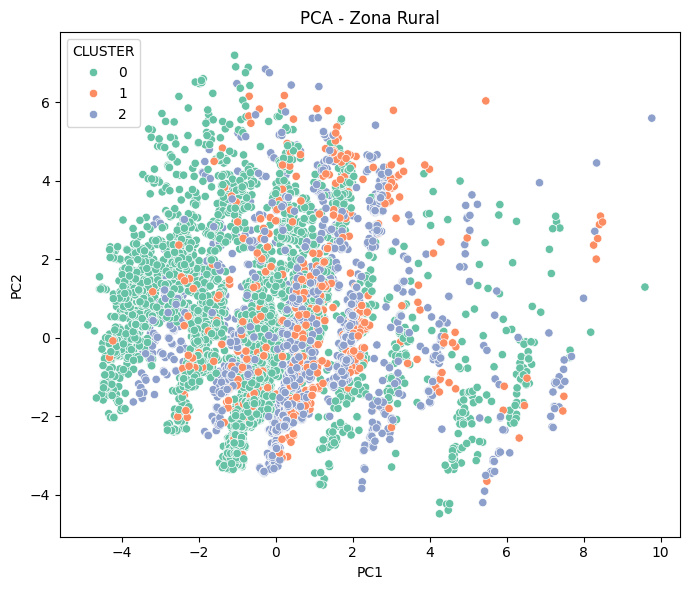

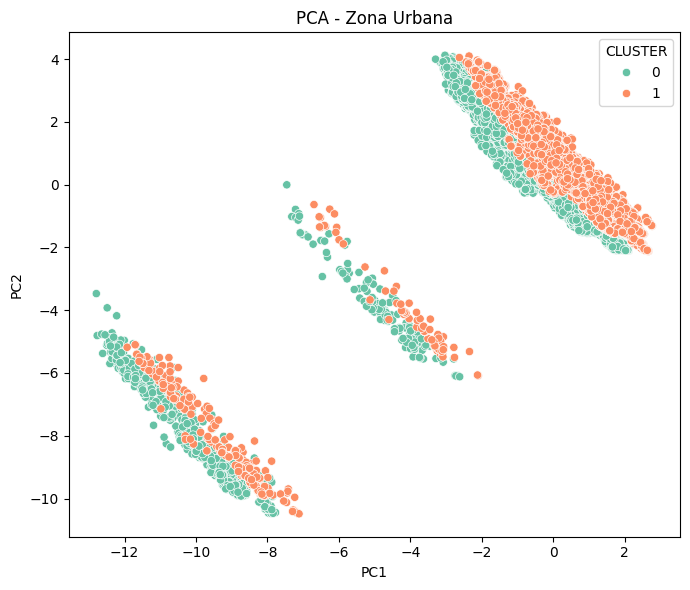

In [25]:
# PCA Rural
plt.figure(figsize=(7, 6))
sns.scatterplot(data=pca_rural_df, x="PC1", y="PC2", hue="CLUSTER", palette="Set2")
plt.title("PCA - Zona Rural")
plt.tight_layout()
plt.show()

# PCA Urbana
plt.figure(figsize=(7, 6))
sns.scatterplot(data=pca_urbana_df, x="PC1", y="PC2", hue="CLUSTER", palette="Set2")
plt.title("PCA - Zona Urbana")
plt.tight_layout()
plt.show()

#### Resultados y Loadings para cada cluster

In [27]:
loadings_rural = pd.DataFrame(
    pca_rural.components_.T,
    columns=[f'PC{i+1}' for i in range(pca_rural.n_components_)],
    index=rural_cols
)


loadings_urbana = pd.DataFrame(
    pca_urbana.components_.T,
    columns=[f'PC{i+1}' for i in range(pca_urbana.n_components_)],
    index=urbana_cols
)

In [28]:
print("Loadings PCA Zona Rural:")
loadings_rural

Loadings PCA Zona Rural:


,PC1,PC2
NUM_COMORBILIDADES,-0.126951,0.013200
PIB,0.073325,0.055720
Total Mujeres,-0.051934,0.054945
TIENE_COMORBILIDAD_True,-0.173312,0.016061
TIENE_COMORBILIDAD_True,-0.173312,0.016061
...,...,...
SEGURIDAD SOCIAL_Vinculado,-0.292151,0.126493
SEGURIDAD SOCIAL_Otro,-0.090164,0.130230
SEGURIDAD SOCIAL_Particular,-0.113618,0.024968
SEGURIDAD SOCIAL_Subsidiado,0.325417,-0.214972


In [29]:
print("Variables más influyentes en PCA Rural:")
loadings_rural_unique = loadings_rural[~loadings_rural.index.duplicated(keep='first')]

abs_loadings_rural = loadings_rural_unique.abs()
top_vars_pc1_rural = abs_loadings_rural['PC1'].sort_values(ascending=False).head(10)
print(top_vars_pc1_rural)

Variables más influyentes en PCA Rural:
SEGURIDAD SOCIAL_Subsidiado                                        0.325417
SEGURIDAD SOCIAL_Vinculado                                         0.292151
ETNIA_Ninguno de las anteriores                                    0.275977
ESTADO_CIVIL_Soltero                                               0.250136
ETNIA_Negro(a), mulato(a), afrocolombiano(a) o afrodescendiente    0.233741
TIENE_COMORBILIDAD_True                                            0.173312
ESTADO_CIVIL_Viudo                                                 0.137305
NUM_COMORBILIDADES                                                 0.126951
SEGURIDAD SOCIAL_Particular                                        0.113618
NIVEL_EDUCACION_Secundaria                                         0.090325
Name: PC1, dtype: float64


In [30]:
explained_var_rural = pca_rural.explained_variance_ratio_
cum_var_rural = np.cumsum(explained_var_rural)

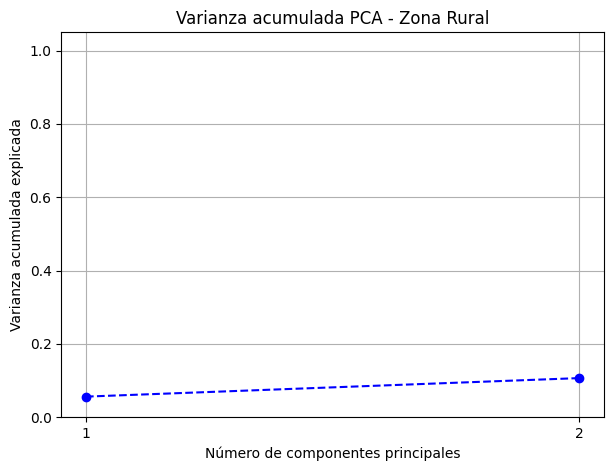

In [31]:
plt.figure(figsize=(7,5))
plt.plot(range(1, len(cum_var_rural)+1), cum_var_rural, marker='o', linestyle='--', color='b')
plt.title('Varianza acumulada PCA - Zona Rural')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza acumulada explicada')
plt.xticks(range(1, len(cum_var_rural)+1))
plt.ylim(0,1.05)
plt.grid(True)
plt.show()

In [32]:
print("Loadings PCA Zona Urbana:")
loadings_urbana

Loadings PCA Zona Urbana:


,PC1,PC2
NUM_COMORBILIDADES,-0.119987,0.000479
PIB,-0.061070,0.037733
Total Mujeres,-0.034271,0.038270
TIENE_COMORBILIDAD_True,-0.116691,0.002227
TIENE_COMORBILIDAD_True,-0.116691,0.002227
...,...,...
SEGURIDAD SOCIAL_Vinculado,-0.016458,0.056991
SEGURIDAD SOCIAL_Otro,-0.029396,0.030099
SEGURIDAD SOCIAL_Particular,0.016621,0.016130
SEGURIDAD SOCIAL_Subsidiado,0.030253,-0.134383


In [33]:
# Quitar variables duplicadas del índice en los loadings de PCA urbana
loadings_urbana_unique = loadings_urbana[~loadings_urbana.index.duplicated(keep='first')]

# Tomar valor absoluto de los loadings para ordenar por magnitud (importancia)
abs_loadings_urbana = loadings_urbana_unique.abs()

# Top 5 variables que más contribuyen a PC1 en zona urbana
top_vars_pc1_urbana = abs_loadings_urbana['PC1'].sort_values(ascending=False).head(10)

print("Variables más influyentes en PC1 (Zona Urbana):")
print(top_vars_pc1_urbana)


Variables más influyentes en PC1 (Zona Urbana):
ETNIA_Ninguno de las anteriores                                    0.371157
ETNIA_Negro(a), mulato(a), afrocolombiano(a) o afrodescendiente    0.365064
NIVEL_EDUCACION_Primaria                                           0.258998
NIVEL_EDUCACION_Secundaria                                         0.242206
ESTADO_CIVIL_Viudo                                                 0.140387
NUM_COMORBILIDADES                                                 0.119987
TIENE_COMORBILIDAD_True                                            0.116691
ESTADO_CIVIL_Soltero                                               0.104452
NIVEL_EDUCACION_Superior                                           0.083456
GRUPO_ETARIO_35-39                                                 0.081657
Name: PC1, dtype: float64


In [34]:
# Para PCA Zona Urbana
explained_var_urbana = pca_urbana.explained_variance_ratio_
cum_var_urbana = np.cumsum(explained_var_urbana)

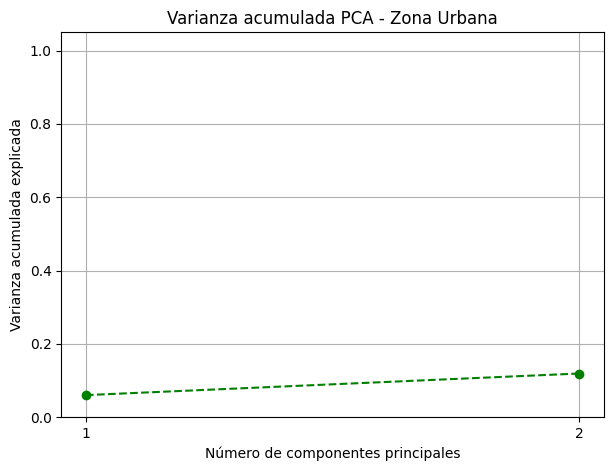

In [35]:
plt.figure(figsize=(7,5))
plt.plot(range(1, len(cum_var_urbana)+1), cum_var_urbana, marker='o', linestyle='--', color='g')
plt.title('Varianza acumulada PCA - Zona Urbana')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza acumulada explicada')
plt.xticks(range(1, len(cum_var_urbana)+1))
plt.ylim(0,1.05)
plt.grid(True)
plt.show()